# Lab 1 · EDA and simple baselines
Pairs · 24 September 2026, 12:30 Santiago · 6% NP.
Read the brief and rubric first. Supplied code supports execution; replace the written prompts and add your own analysis cells. MODE="synthetic" is fictional practice only. Real submission uses snapshot.

In [1]:
from pathlib import Path
import sys, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
for p in (Path.cwd(), *Path.cwd().parents):
    if (p/'labs/lab_01/lab01_support_v1.py').exists():
        ROOT=p; break
else:
    raise FileNotFoundError('Extract the full package and run inside it.')
sys.path.insert(0,str(ROOT/'labs/lab_01'))
from lab01_support_v1 import load_sources,merge_sources,majority_from_train,evaluate
MODE="snapshot"
print('DATA MODE:', MODE, '| Python:',platform.python_version(),'| pandas:',pd.__version__)

DATA MODE: snapshot | Python: 3.12.14 | pandas: 2.3.1


## 1. Target and audit

> 📝 **[ANÁLISIS REQUERIDO - REDACTAR POR EL EQUIPO]**
> - **Question:** ¿Cuál es el momento de predicción, la unidad de observación, la población y el target de este lab?
> - **Evidence:** Definiciones del brief (`IIT414W_Lab1_Brief_v1.md`, sección "Question and prediction moment") + conteos por season de la celda de código siguiente.
> - **Interpretation:** Explicar en sus propias palabras por qué el target (`target_top10`, clasificación final 1-10) es distinto de "completar la carrera" (columnas `status`/`laps`), y por qué la población es retrospectiva (no es una lista de entrada pre-carrera verificada, sino los registros disponibles en el snapshot).
> - **Decision:** Dejar explícito que el momento de predicción es *después de qualy, antes de la carrera*: `qualifying_position` está disponible; `position`, `status`, `points`, `laps` y `grid` todavía no.

In [2]:
q_train,r_train=load_sources('train',ROOT,MODE)
train=merge_sources(q_train,r_train)
display(pd.DataFrame({'qualifying':q_train.groupby('season').size(),'results':r_train.groupby('season').size()}))
display(train.groupby('season').agg(rows=('driver_id','size'),missing_qualifying=('qualifying_position',lambda x:x.isna().sum())))
assert len(train)==len(r_train)
display(train['qualifying_match'].value_counts())

,qualifying,results
season,,
2019,418,420
2020,340,340
2021,439,440


,rows,missing_qualifying
season,,
2019,420,2
2020,340,0
2021,440,1


qualifying_match
both          1197
left_only        3
right_only       0
Name: count, dtype: int64

### Join, keys and coverage audit

> 📝 **[ANÁLISIS REQUERIDO - REDACTAR POR EL EQUIPO]**
> - **Question:** ¿El left join `results ⟵ qualifying` sobre `(season, round, driver_id)` preserva la población de `results` sin duplicar filas, y qué tan completa es la cobertura de `qualifying_position`?
> - **Evidence:** Salida de la celda de código siguiente: conteo de llaves duplicadas, `qualifying_match` value_counts, cobertura de `qualifying_position` por season, y la tabla de disponibilidad temporal de predictores (pre-race vs post-race).
> - **Interpretation:** Explicar qué significan los registros `left_only` (fila de resultado sin fila de qualy correspondiente) y por qué se mantienen en vez de eliminarse.
> - **Decision:** Justificar explícitamente por qué un **inner join** cambiaría la población evaluada (eliminaría los `left_only`, sesgando el dataset hacia pilotos con qualy registrada) y por qué el brief exige left join desde `results`.

In [3]:
dup_keys = train.duplicated(['season', 'round', 'driver_id']).sum()
print('Duplicate (season, round, driver_id) keys in train:', dup_keys)

coverage_by_season = train.groupby('season').agg(
    rows=('driver_id', 'size'),
    matched_qualifying=('qualifying_match', lambda s: (s == 'both').sum()),
    missing_qualifying=('qualifying_position', lambda s: s.isna().sum()),
)
coverage_by_season['coverage_pct'] = (coverage_by_season['matched_qualifying'] / coverage_by_season['rows'] * 100).round(1)
display(coverage_by_season)

inner_join_rows = (train['qualifying_match'] == 'both').sum()
print(f"Rows that would remain under an inner join: {inner_join_rows} of {len(train)} "
      f"({inner_join_rows / len(train) * 100:.1f}%) -- an inner join drops every 'left_only' row.")

predictor_availability = pd.DataFrame({
    'column': ['qualifying_position', 'driver_id', 'constructor_id', 'circuit_id', 'season', 'round',
               'grid', 'position', 'position_text', 'status', 'points', 'laps'],
    'available_pre_race': [True, True, True, True, True, True,
                            False, False, False, False, False, False],
    'note': ['from qualifying table, approved predictor', 'key', 'known before race', 'known before race',
             'known before race', 'known before race',
             'assigned after qualifying/penalties -- NOT an approved predictor (see EDA 2 trap check)',
             'post-race outcome, used only to build the target', 'post-race outcome', 'post-race outcome',
             'post-race outcome', 'post-race outcome'],
})
display(predictor_availability)

Duplicate (season, round, driver_id) keys in train: 0


,rows,matched_qualifying,missing_qualifying,coverage_pct
season,,,,
2019,420,418,2,99.5
2020,340,340,0,100.0
2021,440,439,1,99.8


Rows that would remain under an inner join: 1197 of 1200 (99.8%) -- an inner join drops every 'left_only' row.


,column,available_pre_race,note
0,qualifying_position,True,"from qualifying table, approved predictor"
1,driver_id,True,key
2,constructor_id,True,known before race
3,circuit_id,True,known before race
4,season,True,known before race
5,round,True,known before race
6,grid,False,assigned after qualifying/penalties -- NOT an ...
7,position,False,"post-race outcome, used only to build the target"
8,position_text,False,post-race outcome
9,status,False,post-race outcome


## 2. EDA question 1

**Question:** ¿Qué tan bien predice `qualifying_position` la posición final (`position`), y qué tan fuerte es esa relación en train (2019-2021)?

> 📝 **[ANÁLISIS REQUERIDO - REDACTAR POR EL EQUIPO]**
> - **Question:** (arriba)
> - **Evidence:** Coeficientes de correlación (Pearson y Spearman) entre `qualifying_position` y `position`, el scatter plot, y la tabla de tasa de Top-10 por bucket de `qualifying_position` (celda de código siguiente).
> - **Interpretation:** Comentar la fuerza y forma de la relación (¿es monótona? ¿hay mucha dispersión en las posiciones de qualy media-baja?) citando los valores numéricos observados, no sólo el gráfico.
> - **Decision:** Explicar qué implica esto para la baseline "Qualifying top ten" (regla 2): ¿es razonable esperar que funcione razonablemente bien, o hay un límite claro de cuánto puede acertar usando sólo esta variable?

Pearson r (qualifying_position vs position): 0.630
Spearman rho (qualifying_position vs position, via rank-correlation): 0.630


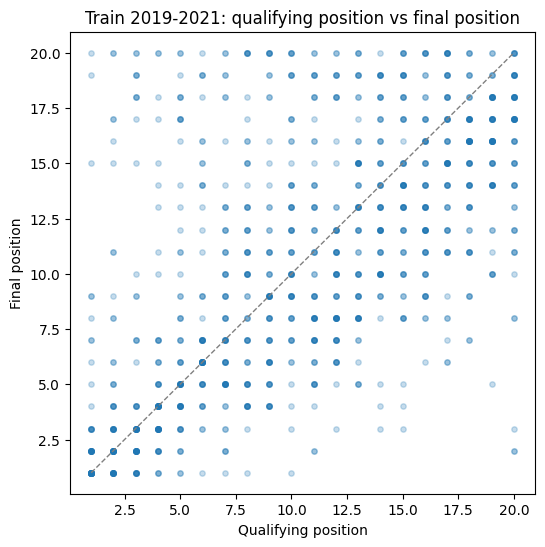

,top10_rate,n
qualifying_bucket,,
1-3,0.883333,180
4-6,0.783333,180
7-10,0.604167,240
11-15,0.400000,300
16+,0.114478,297


In [4]:
corr_pearson = train['qualifying_position'].corr(train['position'], method='pearson')
corr_spearman = train['qualifying_position'].rank().corr(train['position'].rank(), method='pearson')
print(f'Pearson r (qualifying_position vs position): {corr_pearson:.3f}')
print(f'Spearman rho (qualifying_position vs position, via rank-correlation): {corr_spearman:.3f}')

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(train['qualifying_position'], train['position'], alpha=0.25, s=15)
ax.plot([1, 20], [1, 20], linestyle='--', color='gray', linewidth=1)
ax.set_xlabel('Qualifying position')
ax.set_ylabel('Final position')
ax.set_title('Train 2019-2021: qualifying position vs final position')
plt.show()

bins = [0, 3, 6, 10, 15, 21]
labels = ['1-3', '4-6', '7-10', '11-15', '16+']
train_valid = train.dropna(subset=['qualifying_position']).copy()
train_valid['qualifying_bucket'] = pd.cut(train_valid['qualifying_position'], bins=bins, labels=labels, right=True)
top10_rate_by_bucket = train_valid.groupby('qualifying_bucket', observed=True)['target_top10'].agg(['mean', 'count'])
top10_rate_by_bucket.columns = ['top10_rate', 'n']
display(top10_rate_by_bucket)

## 3. EDA question 2 (Trap Check obligatorio)

**Question:** ¿Puede usarse `grid` (grilla real de largada) o variables post-carrera (`laps`, `status`, `points`) como sustituto o predictor de `qualifying_position` / `target_top10`, o es una trampa de fuga/confusión?

> 📝 **[ANÁLISIS REQUERIDO - REDACTAR POR EL EQUIPO]**
> - **Question:** (arriba)
> - **Evidence:** Tabla de discrepancias `grid` vs `qualifying_position` (penalizaciones), conteo de `grid == 0` (salida desde pitlane), y la comparación de `laps`/`status` (variables post-carrera) entre filas top-10 y no-top-10 (celda de código siguiente).
> - **Interpretation:** Explicar por qué `grid` NO es intercambiable con `qualifying_position` (penalizaciones de parrilla decididas después de la clasificación, y `grid == 0` en pitlane rompe la semántica de "posición"), y por qué usar `laps`/`status`/`points` como predictor sería fuga de datos: son resultado de la carrera y casi determinan el target, pero sólo se conocen después de que ocurre lo que se quiere predecir.
> - **Decision:** Confirmar explícitamente que sólo `qualifying_position` (tabla de qualy) se usa como predictor, y que `grid`, `position`, `position_text`, `status`, `points`, `laps` quedan excluidos del pipeline de predicción.

Rows where grid != qualifying_position: 381 of 1197 (31.8%)
Rows with grid == 0 (pitlane start): 29


count    1197.000000
mean       -0.424394
std         2.907493
min       -20.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        18.000000
Name: grid_minus_qualifying, dtype: float64

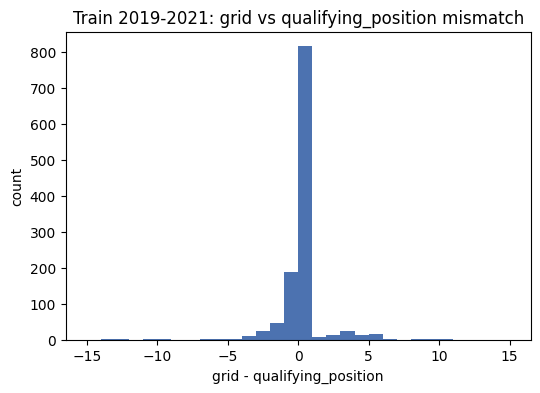

,laps_mean_when_top10,laps_mean_when_not_top10,status_finished_rate_top10,status_finished_rate_not_top10
0,59.765,49.756667,0.831667,0.175


In [5]:
grid_vs_qual = train.dropna(subset=['qualifying_position']).copy()
grid_vs_qual['grid_minus_qualifying'] = grid_vs_qual['grid'] - grid_vs_qual['qualifying_position']
mismatch_rate = (grid_vs_qual['grid_minus_qualifying'] != 0).mean()
print(f"Rows where grid != qualifying_position: {(grid_vs_qual['grid_minus_qualifying'] != 0).sum()} "
      f"of {len(grid_vs_qual)} ({mismatch_rate * 100:.1f}%)")

pitlane_starts = (train['grid'] == 0).sum()
print(f'Rows with grid == 0 (pitlane start): {pitlane_starts}')

display(grid_vs_qual['grid_minus_qualifying'].describe())

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(grid_vs_qual['grid_minus_qualifying'], bins=range(-15, 16), color='#4C72B0')
ax.set_xlabel('grid - qualifying_position')
ax.set_ylabel('count')
ax.set_title('Train 2019-2021: grid vs qualifying_position mismatch')
plt.show()

leakage_check = pd.DataFrame({
    'laps_mean_when_top10': [train.loc[train.target_top10 == 1, 'laps'].mean()],
    'laps_mean_when_not_top10': [train.loc[train.target_top10 == 0, 'laps'].mean()],
    'status_finished_rate_top10': [(train.loc[train.target_top10 == 1, 'status'] == 'Finished').mean()],
    'status_finished_rate_not_top10': [(train.loc[train.target_top10 == 0, 'status'] == 'Finished').mean()],
})
display(leakage_check)

## 4. EDA question 3

**Question:** ¿Cuál es la tasa de conversión a Top-10 y el desbalance de clases del target en train (2019-2021), y es estable entre seasons?

> 📝 **[ANÁLISIS REQUERIDO - REDACTAR POR EL EQUIPO]**
> - **Question:** (arriba)
> - **Evidence:** Tasa global de `target_top10`, desglose por season y gráfico de barras de balance de clases (celda de código siguiente).
> - **Interpretation:** Comentar si el desbalance es fuerte o leve, y si es razonablemente estable año a año dentro de train.
> - **Decision:** Explicar qué implica este desbalance para interpretar accuracy vs balanced accuracy en las baselines, y para la baseline "Training majority" (regla 1) en particular.

Overall Top-10 rate (train 2019-2021): 0.500 (600 of 1200 rows)


,top10_rate,n_top10,n_rows
season,,,
2019,0.5,210,420
2020,0.5,170,340
2021,0.5,220,440


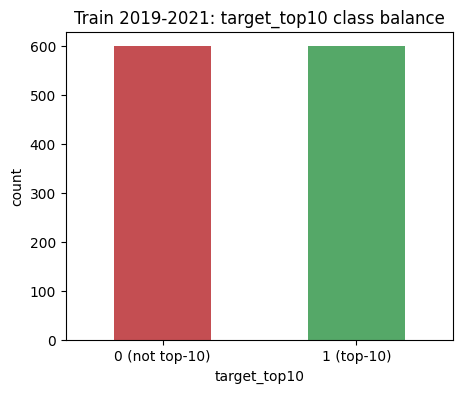

In [6]:
overall_rate = train['target_top10'].mean()
n_total = len(train)
n_top10 = int(train['target_top10'].sum())
print(f'Overall Top-10 rate (train 2019-2021): {overall_rate:.3f} ({n_top10} of {n_total} rows)')

rate_by_season = train.groupby('season')['target_top10'].agg(['mean', 'sum', 'count'])
rate_by_season.columns = ['top10_rate', 'n_top10', 'n_rows']
display(rate_by_season)

fig, ax = plt.subplots(figsize=(5, 4))
train['target_top10'].value_counts().sort_index().plot(kind='bar', ax=ax, color=['#C44E52', '#55A868'])
ax.set_xticklabels(['0 (not top-10)', '1 (top-10)'], rotation=0)
ax.set_ylabel('count')
ax.set_title('Train 2019-2021: target_top10 class balance')
plt.show()

## 5. Baselines and 2022 check

**Reglas fijas (definidas por el brief, no se ajustan con datos):**
- **Regla 1 -- Training majority:** predice para toda fila la clase más frecuente de `target_top10` en train 2019-2021 (empate exacto → 0). Se calcula una única vez (`majority_from_train`) y nunca se recalcula en calibration/test.
- **Regla 2 -- Qualifying top ten:** predice 1 si `qualifying_position <= 10`, si no 0. Si `qualifying_position` falta, usa el fallback de la regla 1 (majority) y se reporta cuántas filas usaron ese fallback.

> 📝 **[ANÁLISIS REQUERIDO - REDACTAR POR EL EQUIPO]**
> - **Question:** ¿Qué supuestos hace cada regla, y en qué escenarios esperarían que cada una falle, ANTES de ver los resultados de calibration?
> - **Evidence:** N/A todavía -- esta es una predicción cualitativa previa; se contrasta después con `evaluate(cal, majority)` de la celda de código siguiente.
> - **Interpretation:** Explicar por qué una referencia trivial (majority) es útil como piso de comparación, y en qué casos la Regla 2 podría acertar o fallar sistemáticamente (por ejemplo, pilotos que califican bien pero abandonan la carrera).
> - **Decision:** Registrar la predicción cualitativa del equipo para poder contrastarla con los resultados reales más abajo.

In [7]:
majority=majority_from_train(train)
print('Training majority:',majority,'| training target rate:',train.target_top10.mean())
q_cal,r_cal=load_sources('calibration',ROOT,MODE)
cal=merge_sources(q_cal,r_cal)
print('Calibration rows:',len(cal),'| missing qualifying:',cal.qualifying_position.isna().sum())
display(evaluate(cal,majority))

Training majority: 0 | training target rate: 0.5


Calibration rows: 440 | missing qualifying: 0


,n,TN,FP,FN,TP,accuracy,balanced_accuracy
majority,440.0,220.0,0.0,220.0,0.0,0.500000,0.500000
qualifying_top10,440.0,168.0,52.0,52.0,168.0,0.763636,0.763636


> 📝 **[ANÁLISIS REQUERIDO - REDACTAR POR EL EQUIPO]**
> - **Question:** ¿Qué dicen TN/FP/FN/TP, accuracy y balanced accuracy (tabla de la celda anterior) sobre el desempeño de cada regla en calibration (2022)?
> - **Evidence:** Tabla `evaluate(cal, majority)` de la celda anterior (fila `majority` vs fila `qualifying_top10`).
> - **Interpretation:** Explicar en este contexto qué significa un falso positivo (predecir top-10 y el piloto no clasificó top-10) y un falso negativo (predecir que no, pero sí clasificó top-10), sin inventar costos monetarios. Comentar si accuracy y balanced accuracy cuentan historias distintas dado el desbalance de clases visto en EDA 3.
> - **Decision:** Registrar si se detectó algún error de implementación durante este check de calibration y cómo se corrigió (ver también el registro de verificación de IA en `PROMPTS_Lab01_v1.md`, sección de verificación, para el detalle de una corrección real hecha por el equipo sobre el cálculo de la mayoría).

## 6. Freeze before final test
Complete this record and commit the code before enabling RUN_TEST.

- **Members and date:** Milan Kurte, Francisco Polo -- 2026-09-24.
- **Target, population, join and prediction moment:** target = `target_top10` (1 if the final numeric `position` is 1-10, else 0); population = driver/race records from the supplied left join of `results` onto `qualifying` on `(season, round, driver_id)`, keeping `left_only`/missing-qualifying rows; prediction moment = after qualifying, before the race (only `qualifying_position` and pre-race identifiers are used as predictors, per Section 1 and the join audit above).
- **Baselines, train majority, threshold and missing policy:** Rule 1 (training majority) computed once from train 2019-2021 in Section 5 above (see the printed value there); Rule 2 (qualifying top ten) uses the fixed threshold `qualifying_position <= 10`, with missing `qualifying_position` falling back to the training majority (fallback count reported in the calibration cell above).
- **Three analysis decisions and changes after calibration:** (1) EDA 1 -- qualifying_position vs final position correlation; (2) EDA 2 -- trap check on `grid` vs `qualifying_position` and post-race leakage variables (`laps`, `status`, `points`); (3) EDA 3 -- Top-10 class balance in train. No rule, threshold or fallback was changed after the calibration check; both baselines remain exactly as specified in the brief and implemented in `lab01_support_v1.py` (unmodified).
- **Frozen code commit/version:** see git tag `lab1-pre-test-freeze` in this repository's commit history.

The test switch is a learning aid. Accessing CSVs directly still counts as inspecting test. Do not change the method in response to test results. Document genuine later bug fixes transparently.

In [8]:
RUN_TEST=False
if RUN_TEST:
    q_test,r_test=load_sources('test',ROOT,MODE,frozen=True)
    test=merge_sources(q_test,r_test)
    print('Test rows:',len(test),'| missing qualifying:',test.qualifying_position.isna().sum())
    display(evaluate(test,majority))
else:
    print('Test remains unopened by this notebook. Complete and commit the freeze record first.')

Test remains unopened by this notebook. Complete and commit the freeze record first.


## 7. Final interpretation and handoff

> 📝 **[ANÁLISIS REQUERIDO - REDACTAR POR EL EQUIPO]**
> - **Question:** ¿Qué regla soportan mejor los datos al comparar calibration (2022) vs test (2023-2024, celda de código anterior), y dónde falla?
> - **Evidence:** Tablas `evaluate(cal, majority)` y `evaluate(test, majority)` (accuracy, balanced accuracy, TN/FP/FN/TP en ambos periodos).
> - **Interpretation:** Comparar si el desempeño de cada regla se mantiene estable entre calibration y test, identificar un failure mode concreto (con ejemplos/valores), y discutir la limitación de que la población es retrospectiva (no es una lista de entrada pre-carrera verificada; ver Sección 1) y que los registros pueden incluir correcciones posteriores a la fecha de carrera.
> - **Decision:** Concluir explícitamente qué regla soporta mejor la evidencia, qué investigarían a continuación, y confirmar que no se modificó ninguna decisión (umbral, fallback, target) después de ver los resultados de test.

Complete RUNBOOK and PROMPTS/contributions; restart/run all and save outputs. Submit the repository URL and final commit via Canvas. No separate report is required.